In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import importlib
import helpers
import xarray as xr
import re
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os


In [ ]:

class CavityCase:
    root_folder='../case_data/'
    def __init__(self, case_number):

        self.case_folder = self.root_folder+str(case_number)+'/'
        result_path = self.case_folder+str(case_number)+'_result.dat'
        self.ds = self._load_results(self.case_folder+str(case_number)+'_result.dat')

        self.res_df, self.meta = self._parse_run_log(self.case_folder+str(case_number)+'_run.log')
        self.solution_method = self.meta["solution_method"]
        self.N = self.meta["N"]
        self.RE = self.meta["RE"]
        self.clock_time = self.meta["clock_time"]
        
        if self.meta["solution_method"] == "fs":
            self.solution_method='EFSM'
            self.time_scheme = self.meta["time_scheme"]
            self.dt = self.meta["DT"]
            self.snapshots, self.snap_times = self._load_snapshots()
        # Extract core fields (assumes names U, V)
        self.U = self.ds["U"].values
        self.V = self.ds["V"].values

        self.x = self.ds["x"].values
        self.y = self.ds["y"].values
        self.X, self.Y = np.meshgrid(self.x, self.y)

        # Derived
        self.velocity_mag = np.sqrt(self.U**2 + self.V**2)
    def _parse_run_log(self, log_path):
        with open(log_path) as f:
            lines = f.readlines()        # --- Residual table ---
        rows = [
            [int(p[0]), int(p[1]), float(p[2]), float(p[3]), float(p[4])]
            for line in lines[1:]
            if re.match(r"\s*\d+", line)
            for p in [line.split()]
            if len(p) >= 5
        ]
        df = pd.DataFrame(rows, columns=["IT", "N", "RESORM", "RESORU", "RESORV"])
        # --- Metadata ---
        text = "".join(lines)
        meta = {}

        def grab(pattern, cast=float, key=None):
            m = re.search(pattern, text)
            if m:
                meta[key] = cast(m.group(1))
        grab(r"Solver:\s*(\w+)", str, "solution_method")
        grab(r"scheme:\s*(\w+)", str, "conv_scheme")
        grab(r"RE=\s*([0-9.E+-]+)", float, "RE")
        grab(r"N=\s*(\d+)", int, "N")
        grab(r"Selected Time scheme:\s*(\d+)", int, "time_scheme")
        grab(r"DT=\s*([0-9.E+-]+)", float, "DT")
        grab(r"URFU=\s*([0-9.E+-]+)", float, "URFU")
        grab(r"Wall-clock time.*:\s*([0-9.E+-]+)", float, "clock_time")
        return df, meta
    def _load_results(self, result_path):
        with open(result_path, "r") as f:
            lines = f.readlines()

        variable_line = next(line for line in lines if "VARIABLES" in line)
        columns = re.findall(r'"(.*?)"', variable_line)

        zone_line = [line for line in lines if "ZONE" in line][0]
        I = int(re.search(r"I=\s*(\d+)", zone_line).group(1))
        J = int(re.search(r"J=\s*(\d+)", zone_line).group(1))
        # print(f"Grid size: I={I}, J={J}")

        # Find data start
        data_start = 0
        for i, line in enumerate(lines):
            if re.match(r"\s*[-+0-9.]", line):
                data_start = i
                break

        data = np.loadtxt(result_path, skiprows=data_start)
        data = data.reshape(J, I, len(columns))
        data_vars = {}
        for k, col in enumerate(columns):
            data_vars[col] = (("y", "x"), data[:, :, k])

        return xr.Dataset(
            data_vars,
            coords={"x": np.arange(I), "y": np.arange(J)},
        )
    def _load_snapshots(self, max_snaps=10):
        snap_dir = self.case_folder + "snaps/"
        if not os.path.exists(snap_dir):
            snapshots, snap_times = [], []
            return
        files = [
            f for f in os.listdir(snap_dir)
            if re.match(r"_snap_([0-9.E+-]+)\.dat", f)
        ]

        # Sort by timestamp
        files = sorted(
            files,
            key=lambda f: float(re.search(r"_snap_([0-9.E+-]+)", f).group(1))
        )

        # Downsample to max_snaps
        if len(files) > max_snaps:
            idx = np.linspace(0, len(files) - 1, max_snaps, dtype=int)
            files = [files[i] for i in idx]

        snapshots = []
        snap_times = []

        for f in files:
            t = float(re.search(r"_snap_([0-9.E+-]+)", f).group(1))
            path = snap_dir + f

            ds = self._load_results(path)
            snapshots.append(ds)
            snap_times.append(t)
        return snapshots, snap_times
    def plot(self, step=3, density=1, scale=2, cmap="plasma"):
        fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

        # --- Contour + quiver ---
        contour = axs[1].contourf(
            self.X, self.Y, self.velocity_mag, levels=10, cmap=cmap
        )

        divider = make_axes_locatable(axs[1])
        cax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(contour, label="Velocity Magnitude", cax=cax, shrink=0.8)

        axs[1].quiver(
            self.X[::step, ::step],
            self.Y[::step, ::step],
            self.U[::step, ::step],
            self.V[::step, ::step],
            color="white",
            scale=scale
        )

        # --- Streamlines ---
        axs[0].streamplot(
            self.X, self.Y, self.U, self.V,
            color='k',
            density=density,
            linewidth=0.8
        )
        # --- Formatting ---
        axs[1].set_title("Velocity Field")
        axs[0].set_title("Velocity Streamlines")

        for ax in axs:
            ax.set_xlim(self.x.min(), self.x.max())
            ax.set_ylim(self.y.min(), self.y.max())
            ax.set_xlabel("X")
            ax.set_ylabel("Y")
            ax.set_aspect('equal', adjustable='box')
        fig.tight_layout()
        return fig, axs
    def animate(self, interval=300, step=3, density=1, scale=2, cmap="plasma", saveFig = False):
        if not hasattr(self, "snapshots") or len(self.snapshots) == 0:
            raise ValueError("No snapshots loaded.")

        fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

        def update(i):
            for ax in axs:
                ax.clear()

            ds = self.snapshots[i]
            U = ds["U"].values
            V = ds["V"].values
            vel = np.sqrt(U**2 + V**2)

            # --- Right: contour + quiver ---
            contour = axs[1].contourf(self.X, self.Y, vel, levels=10, cmap=cmap)

            axs[1].quiver(
                self.X[::step, ::step],
                self.Y[::step, ::step],
                U[::step, ::step],
                V[::step, ::step],
                color="white",
                scale=scale
            )

            # --- Left: streamlines ---
            axs[0].streamplot(
                self.X, self.Y, U, V,
                color='k',
                density=density,
                linewidth=0.8
            )

            # Titles
            t = self.snap_times[i]
            axs[0].set_title(f"Streamlines (t={t:.0f})")
            axs[1].set_title(f"Velocity Field (t={t:.0f})")

            # Formatting
            for ax in axs:
                ax.set_xlim(self.x.min(), self.x.max())
                ax.set_ylim(self.y.min(), self.y.max())
                ax.set_xlabel("X")
                ax.set_ylabel("Y")
                ax.set_aspect('equal', adjustable='box')

        anim = FuncAnimation(
            fig, update,
            frames=len(self.snapshots),
            interval=interval
        )

        plt.close(fig)  # prevent duplicate static plot
        if saveFig:
            anim.save(self.case_folder+"animation.gif", writer="pillow", fps=1000/interval)
        return HTML(anim.to_jshtml())
    def v_horizontal_slice(self, x=0.5):
        return self.ds.V.sel(x=x, method='nearest')
    def u_vertical_slice(self,y=0.5):
        return self.ds.U.sel(y=y, method='nearest')


<xarray.DataArray 'V' (y: 32)> Size: 256B
array([-0.00072304, -0.00225781, -0.00306805, -0.00155413,  0.00349658,
        0.01287754,  0.02685774,  0.04512709,  0.06684491,  0.09077848,
        0.11548643,  0.13949868,  0.16145898,  0.18021519,  0.19485919,
        0.20474082,  0.20941004,  0.20860425,  0.20232665,  0.19088382,
        0.17491517,  0.15542528,  0.13378106,  0.11163578,  0.09077029,
        0.0729197 ,  0.05974328,  0.05310125,  0.05557429,  0.07076839,
        0.08776525,  0.04673447])
Coordinates:
  * y        (y) int64 256B 0 1 2 3 4 5 6 7 8 9 ... 23 24 25 26 27 28 29 30 31
    x        int64 8B 1

(<Figure size 1000x450 with 3 Axes>,
 array([<Axes: title={'center': 'Velocity Streamlines'}, xlabel='X', ylabel='Y'>,
        <Axes: title={'center': 'Velocity Field'}, xlabel='X', ylabel='Y'>],
       dtype=object))

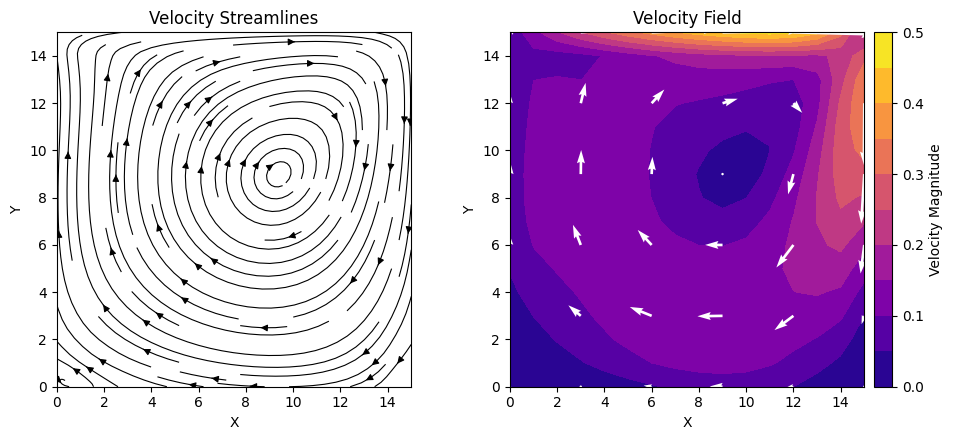

In [ ]:
case_1 = CavityCase(1)
case_1.plot()

In [46]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

def animate_snapshots(snapshots, snap_times, X, Y, step=3, density=1, scale=2, cmap="plasma", interval=300):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

    def update(i):
        for ax in axs:
            ax.clear()

        ds = snapshots[i]
        U = ds["U"].values
        V = ds["V"].values
        vel = np.sqrt(U**2 + V**2)

        # --- Right subplot: contour + quiver ---
        contour = axs[1].contourf(X, Y, vel, levels=10, cmap=cmap)
        divider = make_axes_locatable(axs[1])
        cax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(contour, cax=cax, label="Velocity Magnitude", shrink=0.8)

        axs[1].quiver(
            X[::step, ::step],
            Y[::step, ::step],
            U[::step, ::step],
            V[::step, ::step],
            color="white",
            scale=scale
        )

        # --- Left subplot: streamlines ---
        axs[0].streamplot(
            X, Y, U, V,
            color='k',
            density=density,
            linewidth=0.8
        )

        # Titles
        t = snap_times[i]
        axs[0].set_title(f"Streamlines (t={t:.3f})")
        axs[1].set_title("Velocity Field")

        # Formatting
        for ax in axs:
            ax.set_xlim(X.min(), X.max())
            ax.set_ylim(Y.min(), Y.max())
            ax.set_xlabel("X")
            ax.set_ylabel("Y")
            ax.set_aspect('equal', adjustable='box')

    anim = FuncAnimation(
        fig, update,
        frames=len(snapshots),
        interval=interval
    )

    plt.close(fig)  # prevent duplicate static plot
    return HTML(anim.to_jshtml())
animate_snapshots(case_1.snapshots, case_1.snap_times, case_1.X, case_1.Y, cmap="plasma", scale=2, interval=300, step=3)

In [ ]:
import pandas as pd
import re

def parse_residuals(filename):
    rows = []

    with open(filename, "r") as f:
        lines = f.readlines()

    # Skip first line
    lines = lines[1:]

    for line in lines:
        # Stop when we hit non-numeric section (footer)
        if not re.match(r"\s*\d+", line):
            break

        parts = line.split()

        # Ensure correct number of columns
        if len(parts) >= 5:
            rows.append([
                int(parts[0]),        # IT
                int(parts[1]),        # N
                float(parts[2]),      # RESORM
                float(parts[3]),      # RESORU
                float(parts[4])       # RESORV
            ])

    df = pd.DataFrame(rows, columns=["IT", "N", "RESORM", "RESORU", "RESORV"])
    return df
parse_residuals('../case_data/7/7_run.log')

,IT,N,RESORM,RESORU,RESORV
0,20,556,0.000100,0.997638,0.494557
1,40,333,0.000100,0.577074,0.411551
2,60,230,0.000100,0.477155,0.410684
3,80,182,0.000100,0.475340,0.409639
4,100,168,0.000100,0.476482,0.408635
...,...,...,...,...,...
92,1860,1,0.000055,0.000605,0.000668
93,1880,1,0.000052,0.000574,0.000624
94,1900,1,0.000050,0.000549,0.000576
95,1920,1,0.000047,0.000524,0.000525


In [17]:
import pandas as pd
import re

def parse_solver_output(filename):
    with open(filename) as f:
        lines = f.readlines()

    # --- Residual table ---
    rows = [
        [int(p[0]), int(p[1]), float(p[2]), float(p[3]), float(p[4])]
        for line in lines[1:]
        if re.match(r"\s*\d+", line)
        for p in [line.split()]
        if len(p) >= 5
    ]

    df = pd.DataFrame(rows, columns=["IT", "N", "RESORM", "RESORU", "RESORV"])

    # --- Metadata ---
    text = "".join(lines)
    meta = {}

    def grab(pattern, cast=float, key=None):
        m = re.search(pattern, text)
        if m:
            meta[key] = cast(m.group(1))

    grab(r"Solver:\s*(\w+)", str, "solver")
    grab(r"scheme:\s*(\w+)", str, "scheme")
    grab(r"RE=\s*([0-9.E+-]+)", float, "Re")
    grab(r"N=\s*(\d+)", int, "N")
    grab(r"Selected Time scheme:\s*(\d+)", int, "time_scheme")
    grab(r"DT=\s*([0-9.E+-]+)", float, "dt")
    grab(r"URFU=\s*([0-9.E+-]+)", float, "URFU")
    grab(r"Wall-clock time.*:\s*([0-9.E+-]+)", float, "wall_time")

    return df, meta
parse_solver_output('../case_data/7/7_run.log')

(      IT    N    RESORM    RESORU    RESORV
 0     20  556  0.000100  0.997638  0.494557
 1     40  333  0.000100  0.577074  0.411551
 2     60  230  0.000100  0.477155  0.410684
 3     80  182  0.000100  0.475340  0.409639
 4    100  168  0.000100  0.476482  0.408635
 ..   ...  ...       ...       ...       ...
 92  1860    1  0.000055  0.000605  0.000668
 93  1880    1  0.000052  0.000574  0.000624
 94  1900    1  0.000050  0.000549  0.000576
 95  1920    1  0.000047  0.000524  0.000525
 96  1940    1  0.000045  0.000501  0.000484
 
 [97 rows x 5 columns],
 {'solver': 'fs',
  'scheme': 'quick',
  'Re': 1000.0,
  'N': 32,
  'time_scheme': 1,
  'dt': 0.0250000004,
  'wall_time': 5.9802618})